In [1]:
import sys, os

# Путь к корню проекта
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("PROJECT ROOT:", project_root)
print("PYTHONPATH:", sys.path[:5])

PROJECT ROOT: /home/jovyan/gleb_kmito/AmericanOptionsPricingApproaches
PYTHONPATH: ['/home/jovyan/gleb_kmito/AmericanOptionsPricingApproaches', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '']


In [2]:
import numpy as np
from src.run import run_pricing

/home/jovyan/gleb_kmito/AmericanOptionsPricingApproaches/pricing310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from src.samplers.geometric_brownian_motion_put_sampler import GeometricBrownianMotionPutSampler
from src.pricers.lspi_orig_diploma import LSPIPricerDiploma
from src.pricers.american_monte_carlo import AmericanMonteCarloPricer
# from src.pricers.fqi_pricer import FQIPricerDiploma

params = {
    "asset0": 100.0,
    "sigma": 0.2,
    "r": 0.05,
    "strike": 100.0,
    "t": 1.0,
    "cnt_times": 365,
    "seed": 42,
    "cnt_trajectories": 30_000,
}

In [4]:
LSPIPricerDiploma?

Init signature:
LSPIPricerDiploma(
    sampler: src.samplers.abstract_sampler.SamplerAbstract,
    iterations: int = 25,
    lambda_reg: float = 0.001,
    tol: float = 1e-06,
    debug: bool = False,
    basis_version: str = 'time_buckets',
    n_time_buckets: int = 4,
)
Docstring:      <no docstring>
File:           ~/gleb_kmito/AmericanOptionsPricingApproaches/src/pricers/lspi_orig_diploma.py
Type:           type
Subclasses:     

In [13]:
6.373e+07

1e-1

0.1

In [ ]:
sampler = GeometricBrownianMotionPutSampler(**params)
# pricer = LSPIPricerDiploma(sampler, iterations=25, debug=True)
pricer = LSPIPricerDiploma(sampler, iterations = 25, debug = True, lambda_reg = 1e-1)
amc = AmericanMonteCarloPricer(sampler, degree=3, regularization_alpha=1e-4, debug=True)

history = pricer.price(test=False)
print("LSPI price:", pricer.result["train"])


LSPI iterations:   0%|          | 0/25 [00:00<?, ?it/s]


=== LSPI iteration 0 ===
[LSPI] OTM next states fraction: 0.538
[LSPI] OTM next & cont_next < 0 fraction: 0.000
[LSPI] C1 (continue at s') fraction: 0.538
[LSPI] C2 (exercise/terminal at s') fraction: 0.462


LSPI iterations:   4%|▍         | 1/25 [00:02<00:52,  2.17s/it]

[LSPI] cond(A): 1.943e+07
[LSPI] relative residual ||Aw-b||/||b||: 8.804e-10

=== LSPI iteration 1 ===
[LSPI] OTM next states fraction: 0.538
[LSPI] OTM next & cont_next < 0 fraction: 0.487
[LSPI] C1 (continue at s') fraction: 0.252
[LSPI] C2 (exercise/terminal at s') fraction: 0.748


LSPI iterations:   8%|▊         | 2/25 [00:04<00:46,  2.01s/it]

...

LSPI iterations:  48%|████▊     | 12/25 [00:32<00:38,  2.97s/it]

[LSPI] cond(A): 6.374e+06
[LSPI] relative residual ||Aw-b||/||b||: 1.174e-10

=== LSPI iteration 12 ===
[LSPI] OTM next states fraction: 0.538
[LSPI] OTM next & cont_next < 0 fraction: 0.021
[LSPI] C1 (continue at s') fraction: 0.948
[LSPI] C2 (exercise/terminal at s') fraction: 0.052


LSPI iterations:  48%|████▊     | 12/25 [00:35<00:38,  3.00s/it]

[LSPI] cond(A): 6.374e+06
[LSPI] relative residual ||Aw-b||/||b||: 1.174e-10
[LSPI] converged at iter 12


[policy] payoff==0 & cont<0 & exercise fraction: 0.021
[policy] first 10 time steps bad fraction: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[policy] mean exercise time (years): 0.8676
[policy] fraction exercised before maturity: 0.471
FQI price: {'price': 5.902286763185569, 'std': 8.170962481137552}


In [16]:
price_hist = amc.price(test=False, quiet=True)
print("AMC price:", amc.result["train"])

AMC price train: 100%|██████████| 364/364 [00:00<00:00, 594.16it/s]

[AMC] mean exercise time (years): 0.8102
[AMC] fraction exercised before maturity: 0.442
AMC price: {'price': 6.0293772525633385, 'upper_bound': 12.017255056974827, 'lower_bound': 5.5289395311604235, 'std': 6.877529378183951}


In [8]:
1 / 365

0.0027397260273972603

In [11]:
import math

math.e ** (- 0.05 * (1 / 100))

0.9995001249791693

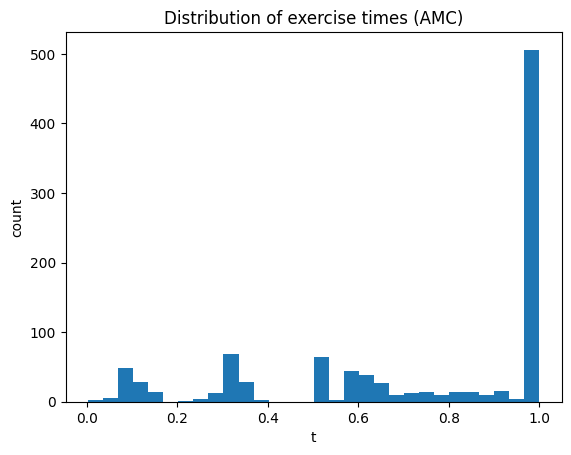

fraction exercised before maturity: 0.524


In [14]:
import matplotlib.pyplot as plt
import numpy as np

time_grid = sampler.time_grid
ex_times_amc = amc.exercise_time_idx

plt.hist(time_grid[ex_times_amc], bins=30)
plt.title("Distribution of exercise times (AMC)")
plt.xlabel("t")
plt.ylabel("count")
plt.show()

print("fraction exercised before maturity:",
      np.mean(ex_times_amc < (sampler.cnt_times - 1)))


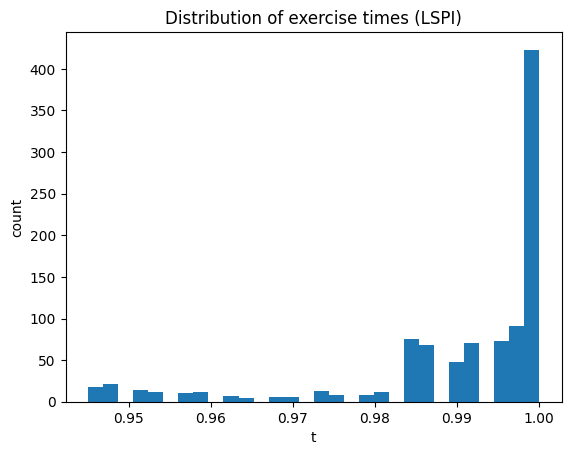

fraction exercised before maturity: 0.577


In [7]:
values, ex_times, cont, exercise_cond = pricer.debug_evaluate_policy()
time_grid = sampler.time_grid

import matplotlib.pyplot as plt

plt.hist(time_grid[ex_times], bins=30)
plt.title("Distribution of exercise times (LSPI)")
plt.xlabel("t")
plt.ylabel("count")
plt.show()

print("fraction exercised before maturity:",
      (ex_times < (sampler.cnt_times - 1)).mean())


bad OTM early exercise fraction: 0.0031098901098901097


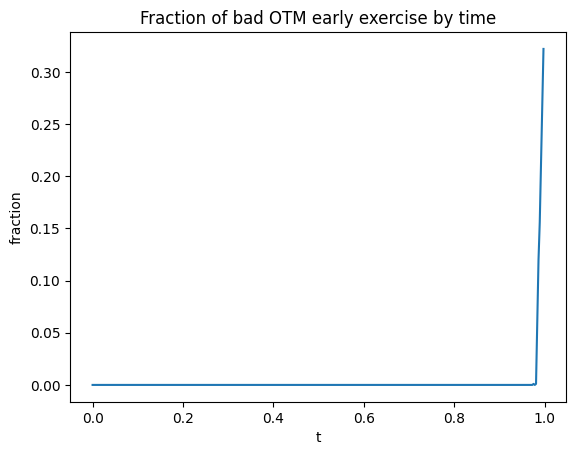

In [ ]:
payoff = sampler.payoff
mask_bad = (payoff[:, :-1] == 0.0) & (cont < 0.0) & exercise_cond
print("bad OTM early exercise fraction:", mask_bad.mean())

# по времени
bad_by_time = mask_bad.mean(axis=0)
plt.plot(time_grid[:-1], bad_by_time)
plt.title("Fraction of bad OTM early exercise by time")
plt.xlabel("t")
plt.ylabel("fraction")
plt.show()

## LSPI


AMC bad OTM early exercise fraction: 0.0


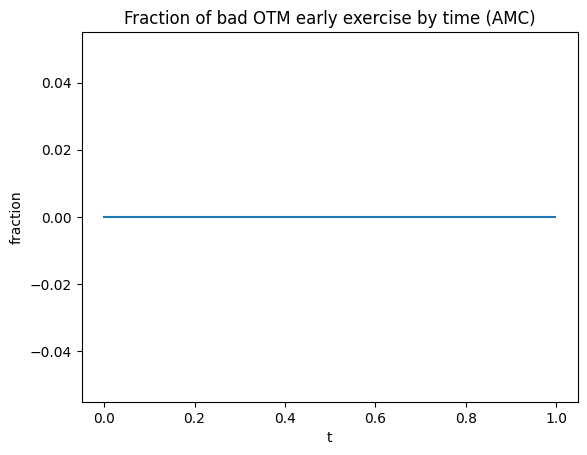

In [15]:
payoff = sampler.payoff
n_traj, n_times = payoff.shape

# собираем exercise_cond по матрице (как мы делали для LSPI)
exercise_cond_amc = np.zeros_like(payoff, dtype=bool)
exercise_cond_amc[np.arange(n_traj), ex_times_amc] = True

mask_bad_amc = (payoff[:, :-1] == 0.0) & exercise_cond_amc[:, :-1]
print("AMC bad OTM early exercise fraction:", mask_bad_amc.mean())

bad_by_time_amc = mask_bad_amc.mean(axis=0)

plt.plot(time_grid[:-1], bad_by_time_amc)
plt.title("Fraction of bad OTM early exercise by time (AMC)")
plt.xlabel("t")
plt.ylabel("fraction")
plt.show()


In [11]:
S = sampler.markov_state[:, :, 0]
T_total = time_grid[-1]

for frac in [0.25, 0.5, 0.75]:
    t_target = frac * T_total
    j = np.argmin(np.abs(time_grid[:-1] - t_target))
    S_slice = S[:, j]
    exercise_slice = exercise_cond[:, j]

    if exercise_slice.any():
        boundary_est = np.median(S_slice[exercise_slice])
    else:
        boundary_est = np.nan

    print(f"t ≈ {time_grid[j]:.3f}, estimated boundary S* ≈ {boundary_est:.2f}")


t ≈ 0.250, estimated boundary S* ≈ nan
t ≈ 0.500, estimated boundary S* ≈ nan
t ≈ 0.750, estimated boundary S* ≈ nan


In [16]:
S = sampler.markov_state[:, :, 0]
T_total = time_grid[-1]

for frac in [0.25, 0.5, 0.75]:
    t_target = frac * T_total
    j = np.argmin(np.abs(time_grid - t_target))  # тут можно по всей сетке, не только[:-1]

    ex_at_j = (ex_times_amc == j)
    if ex_at_j.any():
        boundary_est = np.median(S[ex_at_j, j])
    else:
        boundary_est = np.nan

    print(f"[AMC] t ≈ {time_grid[j]:.3f}, estimated boundary S* ≈ {boundary_est:.2f}")


[AMC] t ≈ 0.250, estimated boundary S* ≈ nan
[AMC] t ≈ 0.500, estimated boundary S* ≈ nan
[AMC] t ≈ 0.750, estimated boundary S* ≈ 88.55


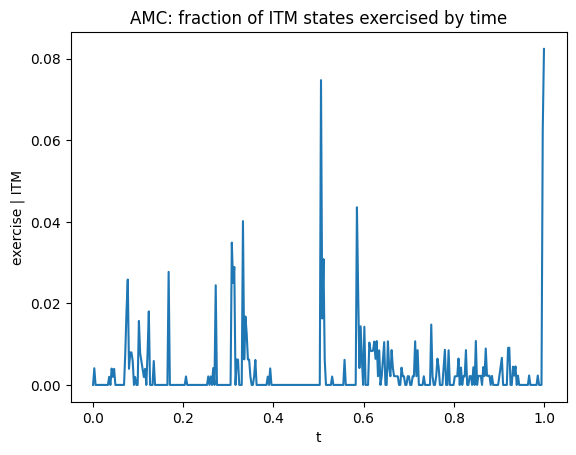

In [17]:
itm = payoff > 0
frac_itm_by_time = itm.mean(axis=0)
frac_exercise_itm_by_time = (exercise_cond_amc & itm).mean(axis=0)

plt.plot(time_grid, frac_exercise_itm_by_time / (frac_itm_by_time + 1e-12))
plt.title("AMC: fraction of ITM states exercised by time")
plt.xlabel("t")
plt.ylabel("exercise | ITM")
plt.show()


## tests

In [6]:
def lspi_value_slice(pricer, t_index, S_min=None, S_max=None, n_S=200):
    """
    Построить срез V(S, t), continuation и payoff по сетке S при фиксированном t_index.

    pricer: экземпляр LSPIPricerDiploma, у которого уже обучен w (после pricer.price(test=False)).
    t_index: индекс по time_grid.
    S_min, S_max: границы по S (если None -> 0.2K..1.8K).
    n_S: количество точек по S.

    Возвращает dict:
        - S_grid: np.ndarray, сетка S
        - payoff: payoff(S_grid)
        - cont: continuation value φ(S,t) @ w
        - V: max(payoff, cont)
        - Q_ex: payoff
        - Q_cont: cont
        - t: значение времени (float)
        - t_index: индекс по времени (int)
    """
    if pricer.w is None:
        raise RuntimeError("LSPI is not trained yet (pricer.w is None). Call pricer.price(test=False) first.")

    K = getattr(pricer.sampler, "strike")
    time_grid = pricer.sampler.time_grid

    if t_index < 0 or t_index >= len(time_grid):
        raise ValueError(f"t_index {t_index} is out of range 0..{len(time_grid)-1}")

    t = time_grid[t_index]

    if S_min is None:
        S_min = 0.2 * K
    if S_max is None:
        S_max = 1.8 * K

    S_grid = np.linspace(S_min, S_max, n_S)
    t_grid = np.full_like(S_grid, t, dtype=float)

    # φ(S,t)
    Phi = pricer._basis_ST(S=S_grid, t=t_grid)
    cont = Phi @ pricer.w

    # для пута
    payoff = np.maximum(K - S_grid, 0.0)
    V = np.maximum(payoff, cont)

    result = {
        "S_grid": S_grid,
        "payoff": payoff,
        "cont": cont,
        "V": V,
        "Q_ex": payoff,
        "Q_cont": cont,
        "t": float(t),
        "t_index": int(t_index),
    }
    return result


In [7]:
def plot_lspi_value_slice(pricer, t_index, S_min=None, S_max=None, n_S=200, ax=None, title_prefix=""):
    """
    Нарисовать payoff(S), continuation(S), V(S) при фиксированном t_index.

    Если ax не передан — создаёт новую фигуру.
    Возвращает ось ax.
    """
    data = lspi_value_slice(pricer, t_index=t_index, S_min=S_min, S_max=S_max, n_S=n_S)

    S = data["S_grid"]
    payoff = data["payoff"]
    cont = data["cont"]
    V = data["V"]
    t = data["t"]
    K = getattr(pricer.sampler, "strike")

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(S, payoff, label="payoff(S)", linewidth=1.5)
    ax.plot(S, cont, label="continuation φ(S,t)^T w", linewidth=1.5)
    ax.plot(S, V, "--", label="V(S,t) = max(payoff, cont)", linewidth=1.5)
    ax.axvline(K, linestyle=":", label="strike K", linewidth=1.0)

    ax.set_xlabel("S")
    ax.set_ylabel("value")
    title = f"Value slice at t={t:.4f}"
    if title_prefix:
        title = f"{title_prefix} | " + title
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

    return ax


In [8]:
def plot_lspi_value_slices(pricer, t_indices, S_min=None, S_max=None, n_S=200,
                           ncols=2, figsize_per_plot=(6, 4)):
    """
    Нарисовать несколько срезов Value/Q по разным моментам времени.

    pricer: LSPIPricerDiploma.
    t_indices: iterable индексов времени (например, [0, 60, 180, 300]).
    ncols: сколько колонок подграфиков.
    figsize_per_plot: размер одной панели (ширина, высота).

    Возвращает (fig, axes).
    """
    t_indices = list(t_indices)
    n_plots = len(t_indices)
    ncols = max(1, ncols)
    nrows = int(np.ceil(n_plots / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        squeeze=False,
    )

    for i, t_idx in enumerate(t_indices):
        r = i // ncols
        c = i % ncols
        ax = axes[r, c]
        plot_lspi_value_slice(
            pricer,
            t_index=t_idx,
            S_min=S_min,
            S_max=S_max,
            n_S=n_S,
            ax=ax,
            title_prefix=f"t_index={t_idx}",
        )

    # скрываем лишние оси, если их больше чем нужно
    for j in range(n_plots, nrows * ncols):
        r = j // ncols
        c = j % ncols
        axes[r, c].axis("off")

    fig.tight_layout()
    return fig, axes


In [9]:
def lspi_policy_slice(pricer, t_index, S_min=None, S_max=None, n_S=400):
    """
    Срез политики по S при фиксированном t_index.

    pricer: LSPIPricerDiploma.
    t_index: индекс по времени.
    Возвращает dict:
        - S_grid
        - exercise: bool-маска: True, если payoff >= cont
        - boundary_S: приближённая граница S*(t) для пута
        - t, t_index
    """
    data = lspi_value_slice(pricer, t_index=t_index, S_min=S_min, S_max=S_max, n_S=n_S)
    S = data["S_grid"]
    payoff = data["payoff"]
    cont = data["cont"]

    # политика: exercise если payoff >= cont
    exercise = payoff >= cont

    # Для пута: ожидаем, что область exercise — на низких S.
    if exercise.any():
        boundary_S = S[exercise].max()  # самый большой S, где ещё исполняем
    else:
        boundary_S = None  # нигде не исполняем

    result = {
        "S_grid": S,
        "exercise": exercise,
        "boundary_S": boundary_S,
        "t": data["t"],
        "t_index": data["t_index"],
    }
    return result


In [10]:
def plot_lspi_policy_slice(pricer, t_index, S_min=None, S_max=None, n_S=400, ax=None):
    """
    Нарисовать payoff/cont и область exercise/continue при фиксированном t_index.

    pricer: LSPIPricerDiploma.
    t_index: индекс времени.
    Возвращает ось ax.
    """
    pol = lspi_policy_slice(pricer, t_index=t_index, S_min=S_min, S_max=S_max, n_S=n_S)
    data = lspi_value_slice(pricer, t_index=t_index, S_min=S_min, S_max=S_max, n_S=n_S)

    S = data["S_grid"]
    payoff = data["payoff"]
    cont = data["cont"]
    exercise = pol["exercise"]
    boundary_S = pol["boundary_S"]
    t = pol["t"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(S, payoff, label="payoff(S)")
    ax.plot(S, cont, label="continuation φ(S,t)^T w")

    # закрасим область exercise
    ax.fill_between(
        S,
        payoff,
        cont,
        where=exercise,
        alpha=0.2,
        label="exercise region (payoff >= cont)",
    )

    if boundary_S is not None:
        ax.axvline(boundary_S, linestyle="--", label=f"S* ≈ {boundary_S:.2f}")

    ax.set_xlabel("S")
    ax.set_ylabel("value")
    ax.set_title(f"Policy slice at t={t:.4f} (t_index={t_index})")
    ax.legend()
    ax.grid(True)

    return ax


In [11]:
def plot_lspi_exercise_boundary(pricer, t_indices, S_min=None, S_max=None, n_S=400, ax=None):
    """
    Построить приблизительную границу exercise S*(t) по набору t_indices.

    pricer: LSPIPricerDiploma.
    t_indices: iterable индексов времени (например, range(0, len(time_grid), 10)).

    Возвращает ось ax.
    """
    time_grid = pricer.sampler.time_grid
    t_indices = list(t_indices)

    t_vals = []
    S_star = []

    for t_idx in t_indices:
        pol = lspi_policy_slice(pricer, t_index=t_idx, S_min=S_min, S_max=S_max, n_S=n_S)
        t_vals.append(time_grid[t_idx])
        boundary_S = pol["boundary_S"]
        if boundary_S is None:
            S_star.append(np.nan)
        else:
            S_star.append(boundary_S)

    t_vals = np.array(t_vals, dtype=float)
    S_star = np.array(S_star, dtype=float)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(t_vals, S_star, marker="o")
    ax.set_xlabel("t")
    ax.set_ylabel("S*(t)")
    ax.set_title("Approximate exercise boundary S*(t) from LSPI policy")
    ax.grid(True)

    return ax


In [21]:
LSPIPricerDiploma?

Init signature:
LSPIPricerDiploma(
    sampler: src.samplers.abstract_sampler.SamplerAbstract,
    iterations: int = 25,
    lambda_reg: float = 0.001,
    tol: float = 1e-06,
    debug: bool = False,
    basis_version: str = 'time_buckets',
    n_time_buckets: int = 4,
)
Docstring:      <no docstring>
File:           ~/gleb_kmito/AmericanOptionsPricingApproaches/src/pricers/lspi_orig_diploma.py
Type:           type
Subclasses:     

In [1]:
import sys, os

# Путь к корню проекта
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("PROJECT ROOT:", project_root)
print("PYTHONPATH:", sys.path[:5])

PROJECT ROOT: /home/jovyan/gleb_kmito/AmericanOptionsPricingApproaches
PYTHONPATH: ['/home/jovyan/gleb_kmito/AmericanOptionsPricingApproaches', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '']


In [2]:
from src.samplers.geometric_brownian_motion_put_sampler import GeometricBrownianMotionPutSampler
from src.pricers.lspi_orig_diploma import LSPIPricerDiploma
from src.pricers.american_monte_carlo import AmericanMonteCarloPricer

/home/jovyan/gleb_kmito/AmericanOptionsPricingApproaches/pricing310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
params = {
    "asset0": 100.0,
    "sigma": 0.2,
    "r": 0.05,
    "strike": 100.0,
    "t": 1.0,
    "cnt_times": 365,
    "seed": 42,
    "cnt_trajectories": 60_000,
}

sampler_train = GeometricBrownianMotionPutSampler(**params)

lspi = LSPIPricerDiploma(
    sampler_train,
    iterations=25,
    lambda_reg=1e-2,
    debug=True,
    basis_version="time_buckets",
    n_time_buckets=4,
)

history = lspi.price(test=False, quiet=False)
print("LSPI train result:", lspi.result["train"])
print("w norm:", np.linalg.norm(lspi.w))
print("feature_std min/max:", lspi.feature_std.min(), lspi.feature_std.max())

LSPI iterations:   0%|          | 0/25 [00:00<?, ?it/s]


=== LSPI iteration 0 ===
[LSPI] cont_next | OTM: min=0.0000, p1=0.0000, p5=0.0000, mean=0.0000, p95=0.0000, max=0.0000
[LSPI] cont_next | ITM: min=0.0000, p1=0.0000, p5=0.0000, mean=0.0000, p95=0.0000, max=0.0000
[LSPI] fraction cont_next < 0 overall: 0.0000
[LSPI] fraction cont_next < 0 in OTM: 0.0000
[LSPI] C1 (continue at s') fraction: 0.539
[LSPI] C2 (exercise/terminal at s') fraction: 0.461
[LSPI] cond(A): 7.832e+09
[LSPI] w_new: norm=690.6526, min=-376.9858, max=327.0329


LSPI iterations:   4%|▍         | 1/25 [00:09<03:39,  9.16s/it]

[LSPI] Phi column norms: min=4.6763e+03, max=6.2425e+03

=== LSPI iteration 1 ===
[LSPI] cont_next | OTM: min=-1.9623, p1=-0.2673, p5=-0.1123, mean=0.1848, p95=0.3451, max=6.8117
[LSPI] cont_next | ITM: min=0.1256, p1=0.3456, p5=0.8034, mean=9.1756, p95=24.2398, max=56.6053
[LSPI] fraction cont_next < 0 overall: 0.0631
[LSPI] fraction cont_next < 0 in OTM: 0.0627
[LSPI] C1 (continue at s') fraction: 0.716
[LSPI] C2 (exercise/terminal at s') fraction: 0.284
[LSPI] cond(A): 4.240e+09
[LSPI] w_new: norm=517.1878, min=-290.3135, max=260.9278


LSPI iterations:   8%|▊         | 2/25 [00:19<03:40,  9.59s/it]

...

LSPI iterations:  44%|████▍     | 11/25 [01:58<02:34, 11.04s/it]

[LSPI] Phi column norms: min=4.6763e+03, max=6.2425e+03

=== LSPI iteration 11 ===
[LSPI] cont_next | OTM: min=-0.5126, p1=-0.0228, p5=0.0407, mean=2.4825, p95=5.7693, max=13.5258
[LSPI] cont_next | ITM: min=0.8073, p1=2.9727, p5=4.9816, mean=11.3778, p95=24.2881, max=61.7862
[LSPI] fraction cont_next < 0 overall: 0.0147
[LSPI] fraction cont_next < 0 in OTM: 0.0144
[LSPI] C1 (continue at s') fraction: 0.947
[LSPI] C2 (exercise/terminal at s') fraction: 0.053
[LSPI] cond(A): 2.799e+09
[LSPI] w_new: norm=363.4818, min=-183.4629, max=216.8580


LSPI iterations:  44%|████▍     | 11/25 [02:09<02:45, 11.81s/it]

[LSPI] Phi column norms: min=4.6763e+03, max=6.2425e+03
[LSPI] converged at iter 11


[policy] payoff==0 & cont<0 & exercise fraction: 0.014
[policy] first 10 time steps bad fraction: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[policy] mean exercise time (years): 0.8552
[policy] fraction exercised before maturity: 0.465
LSPI train result: {'price': 5.9525022860870225, 'std': 7.847127040217066}
w norm: 363.48176092720456
feature_std min/max: 0.02876514427093054 4.6604401815387275


In [5]:
# %%  Rebuild (A, b) on the training dataset and check A w ≈ b

# Данные обучения — это те же траектории, на которых только что обучали LSPI
X_raw, X_next_raw, g_next, terminal = lspi._build_dataset()
Phi_raw, Phi_next_raw = lspi._fit_features(X_raw, X_next_raw)

Phi = Phi_raw / lspi.feature_std
Phi_next = Phi_next_raw / lspi.feature_std

gamma = lspi.gamma
w = lspi.w.copy()

cont_next = Phi_next @ w
ex_next = g_next

C1 = (~terminal) & (cont_next >= ex_next)
C2 = terminal | (cont_next < ex_next)

Y = Phi.copy()
Y[C1] -= gamma * Phi_next[C1]

v_vec = np.zeros(Phi.shape[0], dtype=float)
v_vec[C2] = gamma * g_next[C2]

A = Phi.T @ Y
if lspi.lambda_reg > 0:
    A += lspi.lambda_reg * np.eye(Phi.shape[1])

b = Phi.T @ v_vec

w_from_Ab = np.linalg.pinv(A, rcond=1e-10) @ b

print("‖w_from_Ab‖:", np.linalg.norm(w_from_Ab))
print("‖w_from_Ab - w‖:", np.linalg.norm(w_from_Ab - w))
print("‖A w - b‖:", np.linalg.norm(A @ w - b))


‖w_from_Ab‖: 363.48176092720456
‖w_from_Ab - w‖: 0.0
‖A w - b‖: 1.2378112583730618


Bellman-like residual:
  mean = -0.0006992659705312034
  std  = 0.5099398553318167
  min  = -4.244167587058872
  max  = 9.087540912306736


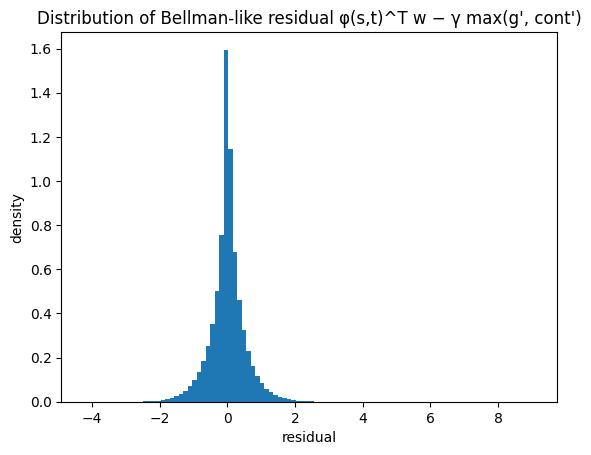

In [6]:
# %%  Bellman-like residual diagnostics

# текущие состояния
S = lspi.sampler.markov_state[:, :, 0]
time_grid = lspi.sampler.time_grid
n_traj, n_times = S.shape

S_curr = S[:, :-1].reshape(-1)
t_curr = np.broadcast_to(time_grid[:-1], (n_traj, n_times - 1)).reshape(-1)

Phi_curr_raw = lspi._basis_ST(S_curr, t_curr)
Phi_curr = Phi_curr_raw / lspi.feature_std
cont_curr = Phi_curr @ w

# next уже есть: Phi_next, g_next, terminal
value_next = np.maximum(g_next, cont_next)
rhs = gamma * value_next
residual = cont_curr - rhs

print("Bellman-like residual:")
print("  mean =", residual.mean())
print("  std  =", residual.std())
print("  min  =", residual.min())
print("  max  =", residual.max())

plt.figure()
plt.hist(residual, bins=100, density=True)
plt.title("Distribution of Bellman-like residual φ(s,t)^T w − γ max(g', cont')")
plt.xlabel("residual")
plt.ylabel("density")
plt.show()


In [7]:
# %%  Out-of-sample evaluation of LSPI policy

def evaluate_lspi_out_of_sample(
    base_params,
    pricer_trained: LSPIPricerDiploma,
    n_scenarios: int = 20,
    n_paths: int | None = None,
    first_seed: int = 100,
):
    prices = []
    all_results = []

    for k in range(n_scenarios):
        p = dict(base_params)
        p["seed"] = first_seed + k
        if n_paths is not None:
            p["cnt_trajectories"] = n_paths

        sampler_test = GeometricBrownianMotionPutSampler(**p)
        pricer_test = LSPIPricerDiploma(
            sampler_test,
            iterations=0,            # не переобучаем
            lambda_reg=pricer_trained.lambda_reg,
            basis_version=pricer_trained.basis_version,
            n_time_buckets=pricer_trained.n_time_buckets,
        )
        # подставляем обученные параметры
        pricer_test.w = pricer_trained.w.copy()
        pricer_test.feature_std = pricer_trained.feature_std.copy()
        pricer_test.gamma = pricer_trained.gamma

        # считаем цену по политике (режим test=True не делает итераций LSPI)
        pricer_test.price(test=True, quiet=True)
        price0 = pricer_test.result["test"]["price"]
        prices.append(price0)
        all_results.append(pricer_test.result["test"])

    prices = np.asarray(prices)
    return {
        "mean_price": float(prices.mean()),
        "std_price": float(prices.std()),
        "all_prices": prices,
    }

lspi_oos = evaluate_lspi_out_of_sample(params, lspi, n_scenarios=20)
print("LSPI out-of-sample mean ± std:",
      lspi_oos["mean_price"], "±", lspi_oos["std_price"])
print("Individual prices:", lspi_oos["all_prices"])


GBM sampling: 100%|██████████| 364/364 [00:00<00:00, 851.78it/s]


LSPI out-of-sample mean ± std: 5.995269879848283 ± 0.03521113237583276
Individual prices: [5.98102136 6.02581126 6.03003827 6.03450282 5.93730864 6.00844616
 5.96736928 5.99952764 6.01665735 5.92825086 5.96477706 6.01497712
 6.00938247 5.9987836  5.94921177 6.04783192 6.01971401 6.0175268
 6.01877758 5.93548162]


AMC price train:  91%|█████████ | 330/364 [00:01<00:00, 331.85it/s]/home/jovyan/gleb_kmito/AmericanOptionsPricingApproaches/src/pricers/american_monte_carlo.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
AMC price train: 100%|██████████| 364/364 [00:01<00:00, 321.43it/s]


AMMC train result: {'price': 6.059730545795638, 'upper_bound': 12.036444198726668, 'lower_bound': 5.5396151015150386, 'std': 6.97517405462175}


AMC price train: 100%|██████████| 364/364 [00:00<00:00, 374.53it/s]


AMMC out-of-sample mean ± std: 6.085278667099879 ± 0.02632950138153153
Individual prices: [6.11160491 6.10244283 6.10006713 6.07867731 6.08522851 6.07638022
 6.07109047 6.04577222 6.09767759 6.07372442 6.07024232 6.10629209
 6.11196143 6.11993251 6.09912175 6.04289901 6.05471802 6.06545607
 6.14280761 6.0494769 ]


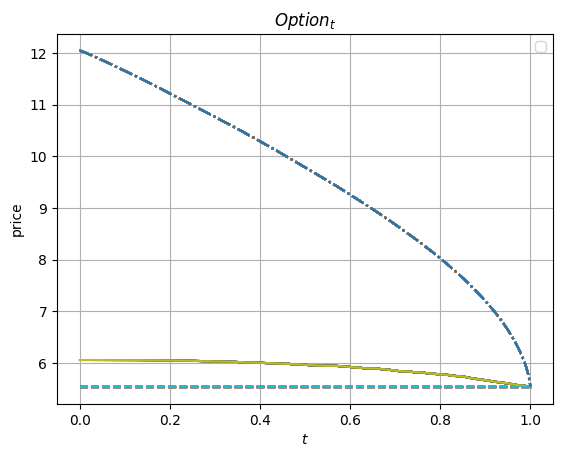

In [8]:
# %%  American Monte Carlo (LSMC) comparison

sampler_amc = GeometricBrownianMotionPutSampler(**params)
amc = AmericanMonteCarloPricer(sampler_amc)

amc_history = amc.price(test=False, quiet=False)
print("AMMC train result:", amc.result["train"])

# out-of-sample для LSMC (чисто для сравнения стабильности)
def evaluate_amc_out_of_sample(
    base_params,
    n_scenarios: int = 20,
    n_paths: int | None = None,
    first_seed: int = 200,
):
    prices = []

    for k in range(n_scenarios):
        p = dict(base_params)
        p["seed"] = first_seed + k
        if n_paths is not None:
            p["cnt_trajectories"] = n_paths

        sampler = GeometricBrownianMotionPutSampler(**p)
        pricer = AmericanMonteCarloPricer(sampler)
        pricer.price(test=False, quiet=True)
        prices.append(pricer.result["train"]["price"])

    prices = np.asarray(prices)
    return {
        "mean_price": float(prices.mean()),
        "std_price": float(prices.std()),
        "all_prices": prices,
    }

amc_oos = evaluate_amc_out_of_sample(params, n_scenarios=20)
print("AMMC out-of-sample mean ± std:",
      amc_oos["mean_price"], "±", amc_oos["std_price"])
print("Individual prices:", amc_oos["all_prices"])


In [ ]:
# %% CV LSMC vs CV LSPI vs payoff + exercise boundary (без переобучения)

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Если у тебя уже есть find_rightmost_root – используем его, иначе определим
try:
    find_rightmost_root
except NameError:
    from scipy import optimize

    def find_rightmost_root(f, bounds, n_grid: int = 100):
        """
        Ищет правый (по x) корень f(x)=0 в интервале bounds=(a,b).
        """
        a, b = bounds
        xs = np.linspace(a, b, n_grid)
        vals = f(xs)

        root_interval = None
        for x_left, x_right, v_left, v_right in zip(xs[:-1], xs[1:], vals[:-1], vals[1:]):
            if np.isnan(v_left) or np.isnan(v_right):
                continue
            if v_left == 0.0:
                root_interval = (x_left, x_left)
            if v_left * v_right < 0.0:
                root_interval = (x_left, x_right)

        if root_interval is None:
            return None

        x_left, x_right = root_interval
        if x_right > x_left:
            try:
                r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
                return float(r)
            except ValueError:
                pass

        return float(x_left)


def amc_continuation_value_at_index(pricer_amc, S, time_index: int):
    """
    Continuation value AMC в момент времени по индексу time_index.

    Использует уже обученные:
      - pricer_amc.weights[time_index]
      - pricer_amc.scalers[time_index]
      - pricer_amc.basis_functions_transformer
      - pricer_amc.option_price
    Ничего не дообучает.
    """
    S_arr = np.asarray(S, dtype=float).reshape(-1, 1)

    # В коде AMC для time_index==0 continuation == mean(option_price)
    if time_index == 0:
        return np.full(S_arr.shape[0], pricer_amc.option_price.mean(), dtype=float)

    if time_index >= len(pricer_amc.weights):
        time_index = len(pricer_amc.weights) - 1

    w = pricer_amc.weights[time_index]
    scaler = pricer_amc.scalers[time_index]

    # Если на этом шаге регрессия не обучалась (мало ITM и т.п.)
    if w is None or scaler is None:
        return np.zeros(S_arr.shape[0], dtype=float)

    features_scaled = scaler.transform(S_arr)
    Phi = pricer_amc.basis_functions_transformer.transform(features_scaled)
    vals = Phi @ w
    return vals.ravel()


def lspi_continuation_value(pricer_lspi, S, t):
    """
    Continuation value LSPI: C(S,t) = φ(S,t)^T w.
    Работает для скаляров и массивов.
    """
    if pricer_lspi.w is None or pricer_lspi.feature_std is None:
        raise RuntimeError("LSPI must be trained (price(test=False)) before calling continuation_value.")

    S_arr = np.asarray(S, dtype=float)
    t_arr = np.asarray(t, dtype=float)

    if t_arr.ndim == 0:
        t_arr = np.full_like(S_arr, t_arr, dtype=float)
    else:
        t_arr = np.broadcast_to(t_arr, S_arr.shape)

    Phi_raw = pricer_lspi._basis_ST(S_arr, t_arr)
    Phi = Phi_raw / pricer_lspi.feature_std
    vals = Phi @ pricer_lspi.w
    return vals.ravel()


def plot_lsmc_lspi_exercise_boundary(
    pricer_lsmc: AmericanMonteCarloPricer,
    pricer_lspi: LSPIPricerDiploma,
    show_all_time_plots: bool = True,
    n_plot_times: int = 20,
):
    """
    Строит:
      1) Для выбранных n_plot_times моментов t график CV_lsmc, CV_lspi и payoff
         (если show_all_time_plots=True)
      2) Общий график exercise boundary во времени.

    Ничего не переобучает, использует уже обученные pricer_lsmc и pricer_lspi.
    """
    sampler = pricer_lspi.sampler
    K = getattr(sampler, "strike")
    time_grid = sampler.time_grid
    n_times = len(time_grid)

    exercise_boundary_lsmc = []
    exercise_boundary_lspi = []

    # индексы временных моментов, для которых будем рисовать CV-графики
    if show_all_time_plots:
        n_plot_times = min(n_plot_times, n_times)
        plot_indices = set(
            np.linspace(0, n_times - 1, n_plot_times, dtype=int)
        )
    else:
        plot_indices = set()

    for i, t in tqdm(list(enumerate(time_grid)), desc="exercise boundary"):
        # payoff пута
        func_payoff = lambda x: np.clip(K - x, a_min=0.0, a_max=np.inf)

        # continuation values
        func_continuation_value_lsmc = lambda x, idx=i: amc_continuation_value_at_index(pricer_lsmc, x, idx)
        func_continuation_value_lspi = lambda x, tt=t: lspi_continuation_value(pricer_lspi, x, tt)

        # границы поиска корня
        left = np.percentile(sampler.markov_state[:, i, 0], 0.99) - 1e-6
        right = K
        if left >= right:
            left = 0.5 * K

        root_lsmc = find_rightmost_root(
            f=lambda x: func_payoff(x) - func_continuation_value_lsmc(x),
            bounds=(left, right),
        )
        root_lspi = find_rightmost_root(
            f=lambda x: func_payoff(x) - func_continuation_value_lspi(x),
            bounds=(left, right),
        )

        exercise_boundary_lsmc.append(root_lsmc)
        exercise_boundary_lspi.append(root_lspi)

        # рисуем только для выбранных индексов
        if show_all_time_plots and i in plot_indices:
            plt.figure(figsize=(10, 6))
            plt.title(f"Continuation value at t={t:.4f} (index {i})")

            grid = np.linspace(left, right, 30)
            cv_lsmc_vals = func_continuation_value_lsmc(grid)
            cv_lspi_vals = func_continuation_value_lspi(grid)

            plt.plot(grid, cv_lsmc_vals, label="CV LSMC")
            plt.plot(grid, cv_lspi_vals, label="CV LSPI")
            plt.plot(grid, func_payoff(grid), label="Payoff")

            if root_lsmc is not None:
                plt.axvline(root_lsmc, linestyle="--", color="black", linewidth=1)
            if root_lspi is not None:
                plt.axvline(root_lspi, linestyle="--", color="black", linewidth=1)

            plt.xlabel("S")
            plt.ylabel("value")
            plt.legend()
            plt.grid(True)
            plt.show()

    # итоговый график границ
    plt.figure(figsize=(10, 6))
    plt.title("Exercise Boundary")
    plt.plot(time_grid, exercise_boundary_lsmc, "-o", markersize=2, label="lsmc")
    plt.plot(time_grid, exercise_boundary_lspi, "-o", markersize=2, label="lspi")
    plt.xlabel("t")
    plt.ylabel("S*(t)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return np.array(exercise_boundary_lsmc), np.array(exercise_boundary_lspi)



exercise boundary:   0%|          | 0/365 [00:00<?, ?it/s]

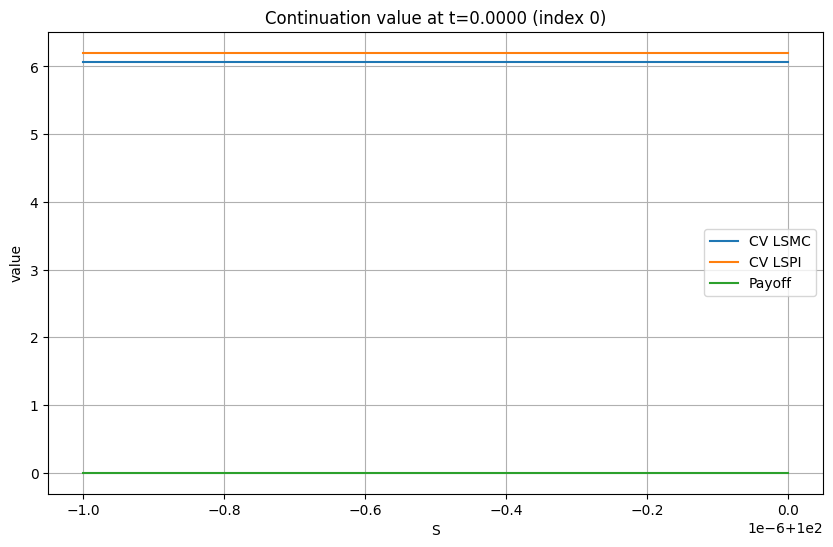

exercise boundary:   0%|          | 1/365 [00:00<00:50,  7.24it/s]

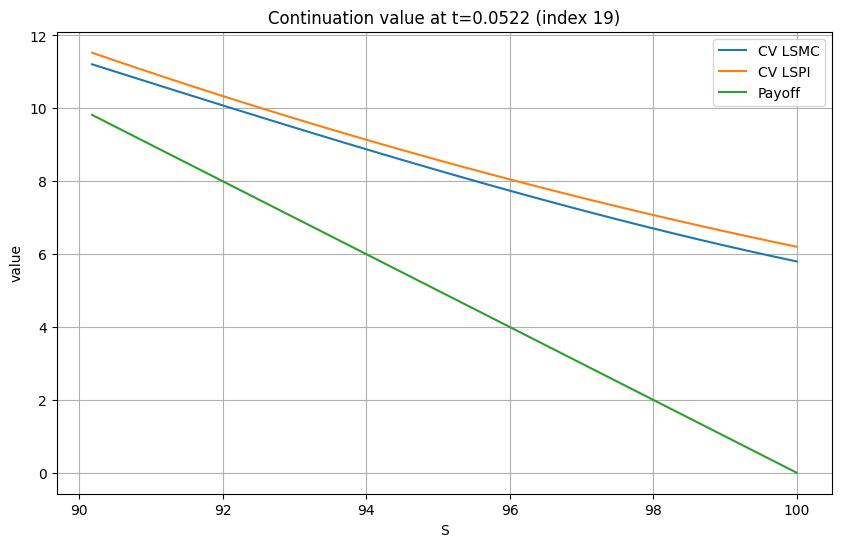

exercise boundary:   5%|▌         | 20/365 [00:00<00:04, 72.14it/s]

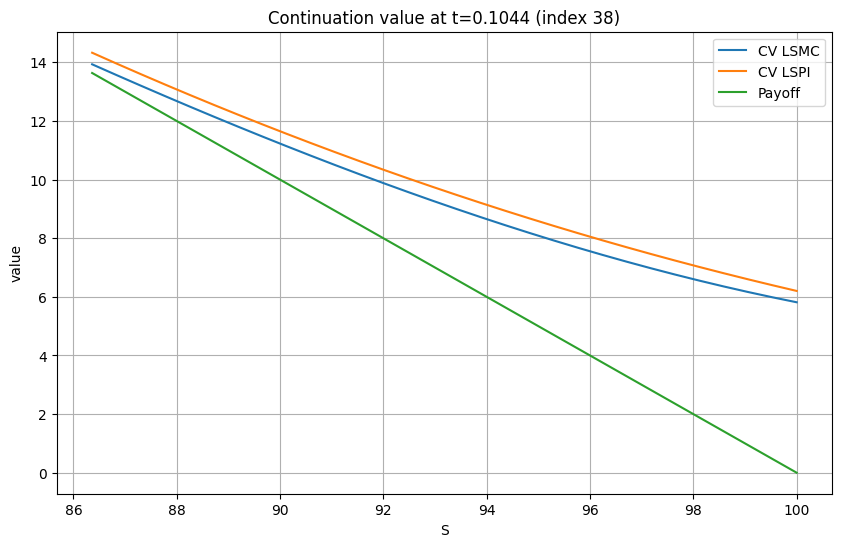

exercise boundary:  11%|█         | 39/365 [00:00<00:03, 86.16it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lam

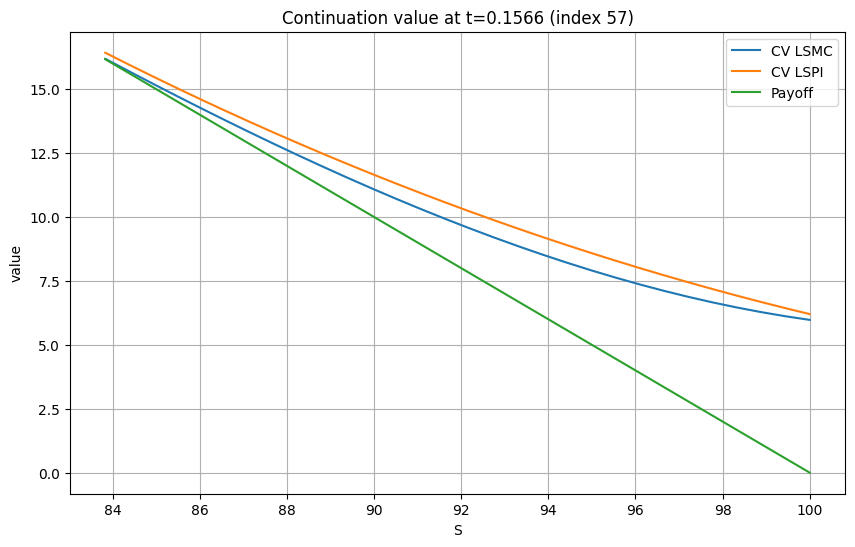

exercise boundary:  16%|█▌        | 58/365 [00:00<00:03, 90.21it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lam

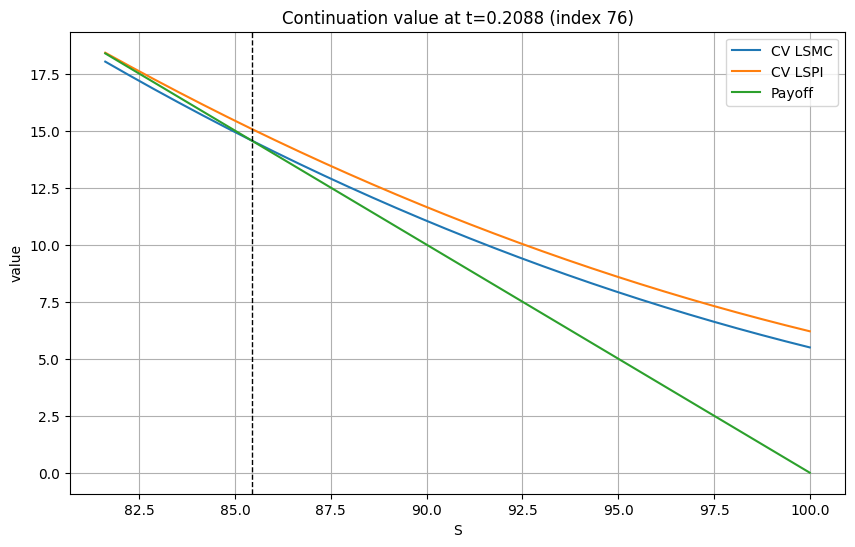

exercise boundary:  21%|██        | 77/365 [00:00<00:03, 89.59it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lam

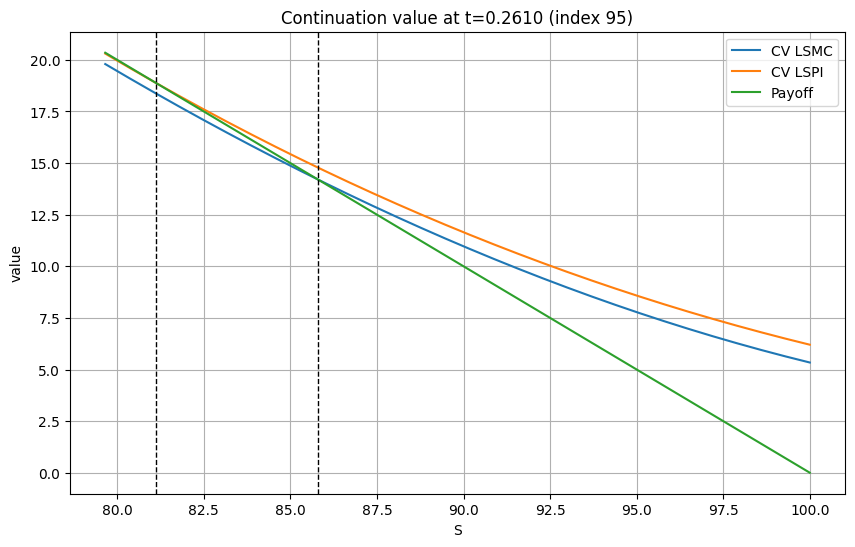

exercise boundary:  26%|██▋       | 96/365 [00:01<00:03, 86.53it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lam

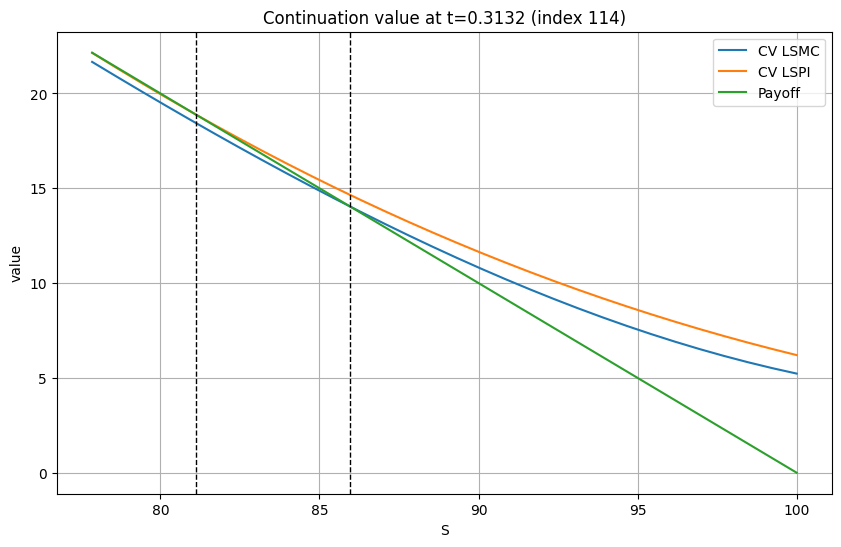

exercise boundary:  32%|███▏      | 115/365 [00:01<00:02, 88.87it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

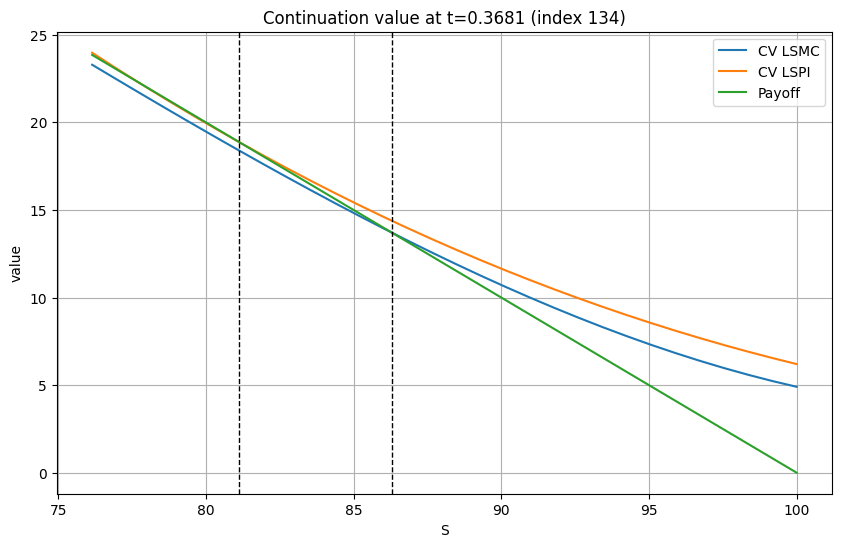

exercise boundary:  37%|███▋      | 135/365 [00:01<00:02, 90.51it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

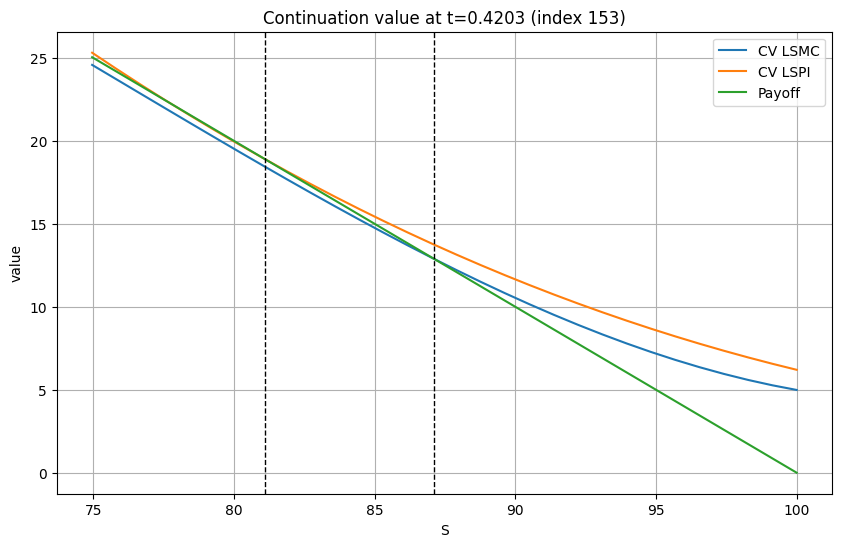

exercise boundary:  42%|████▏     | 154/365 [00:01<00:02, 90.61it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

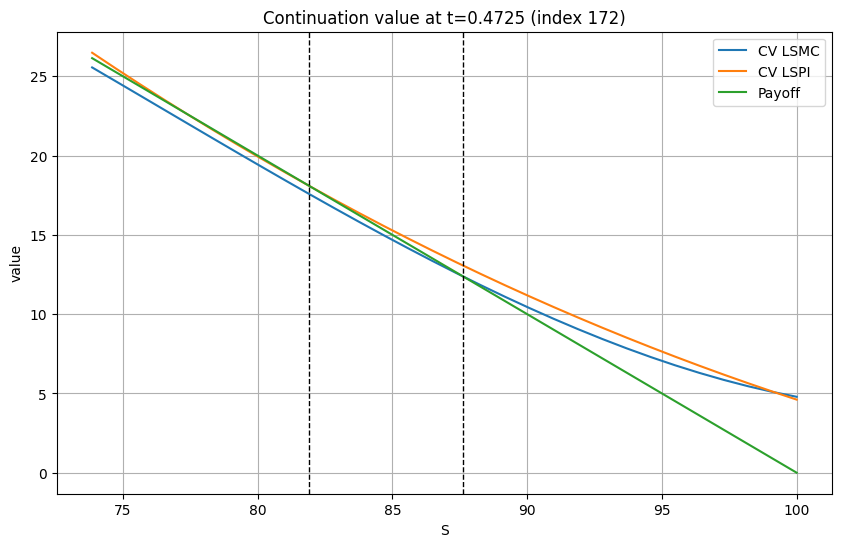

exercise boundary:  47%|████▋     | 173/365 [00:01<00:02, 90.94it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

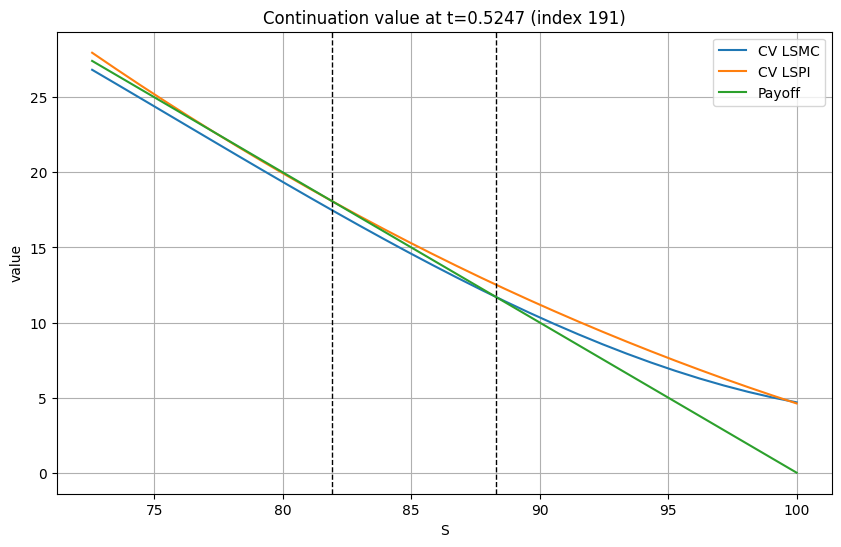

exercise boundary:  53%|█████▎    | 192/365 [00:02<00:01, 91.34it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

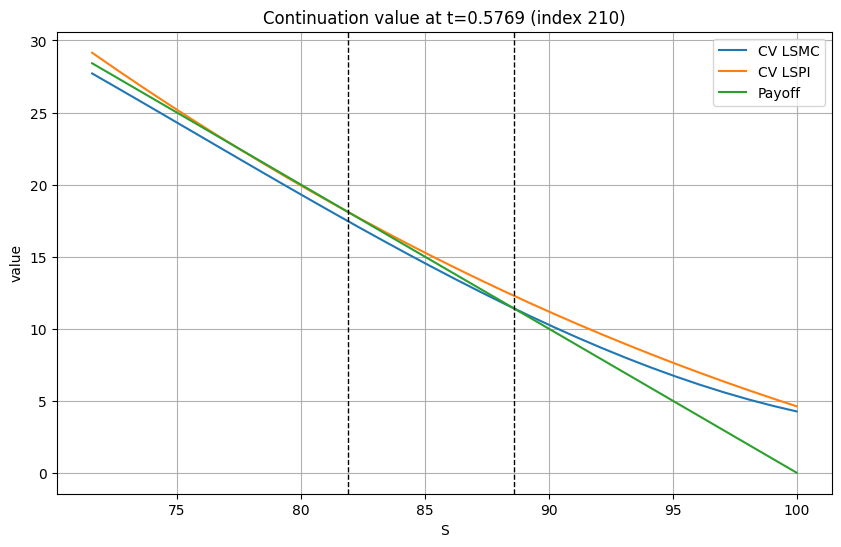

exercise boundary:  58%|█████▊    | 211/365 [00:02<00:01, 83.75it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

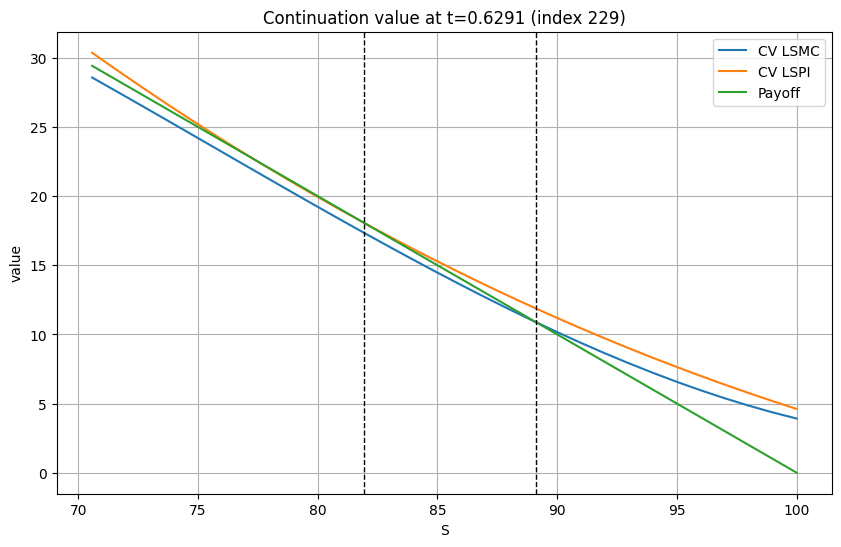

exercise boundary:  63%|██████▎   | 230/365 [00:02<00:01, 84.82it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

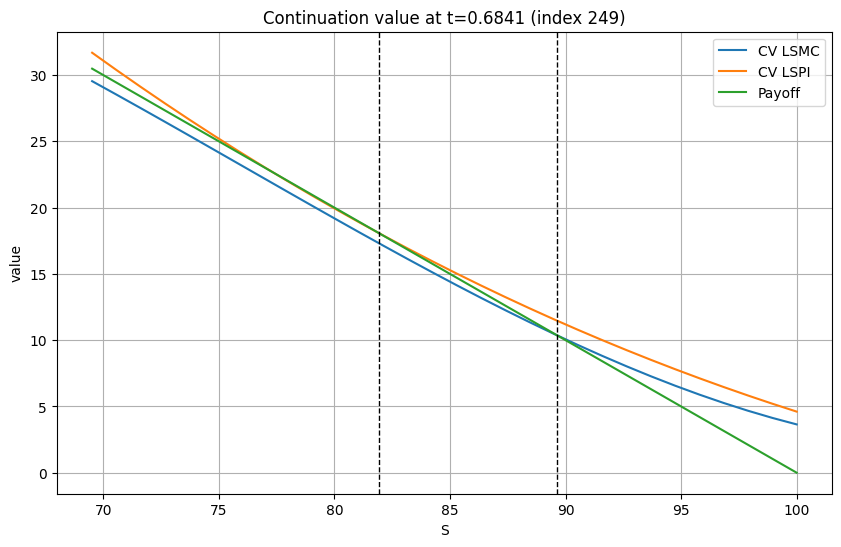

exercise boundary:  68%|██████▊   | 250/365 [00:02<00:01, 86.56it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

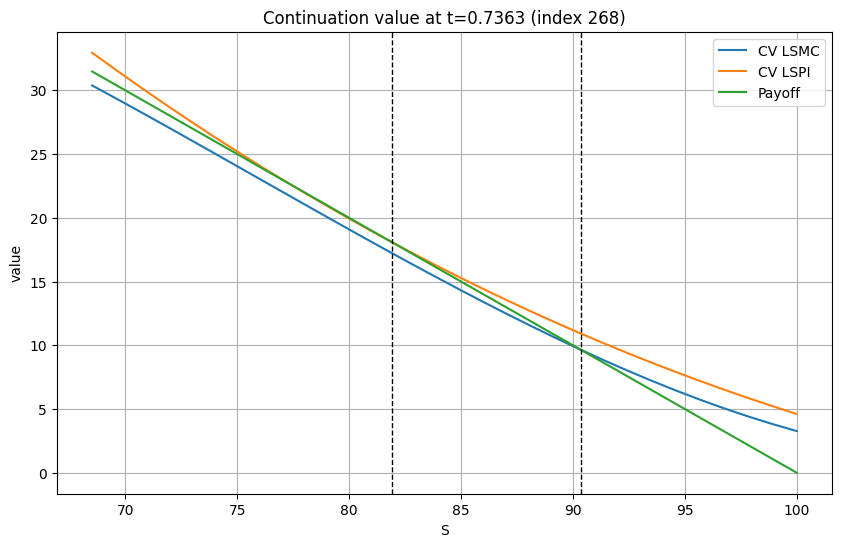

exercise boundary:  74%|███████▎  | 269/365 [00:03<00:01, 86.81it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

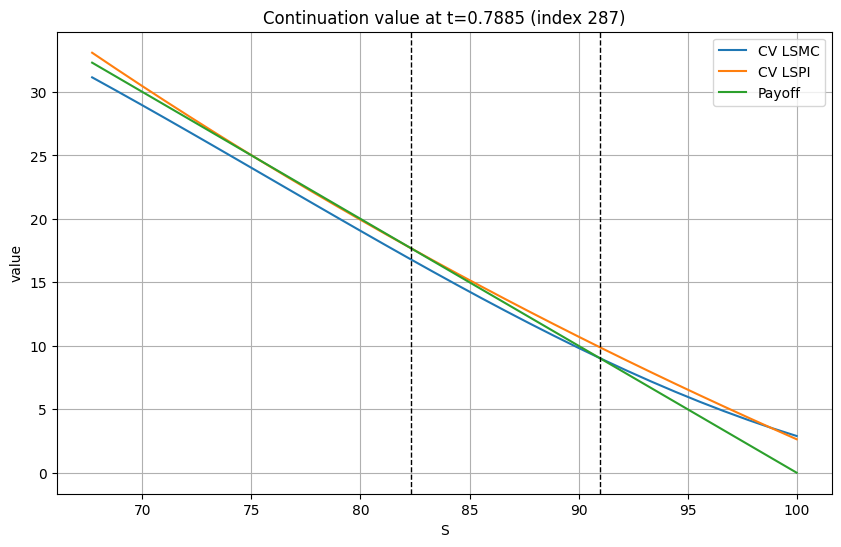

exercise boundary:  79%|███████▉  | 288/365 [00:03<00:00, 87.01it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

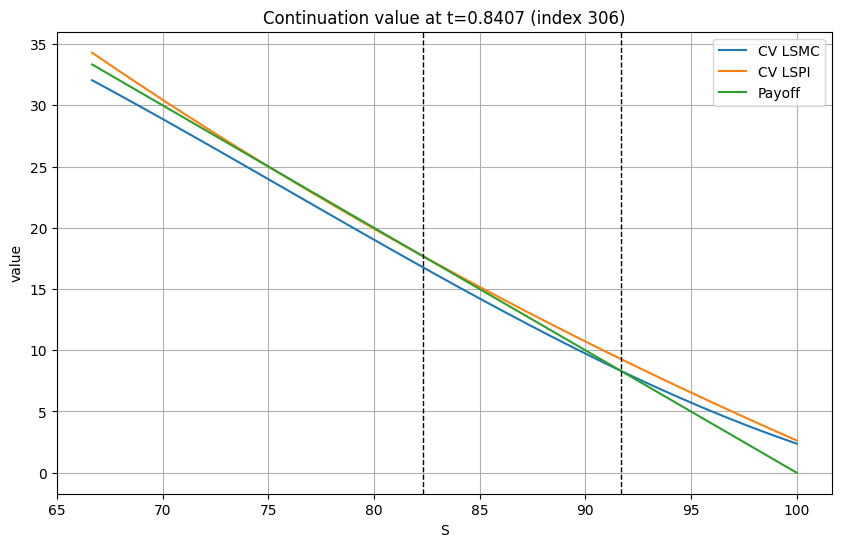

exercise boundary:  84%|████████▍ | 307/365 [00:03<00:00, 85.98it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

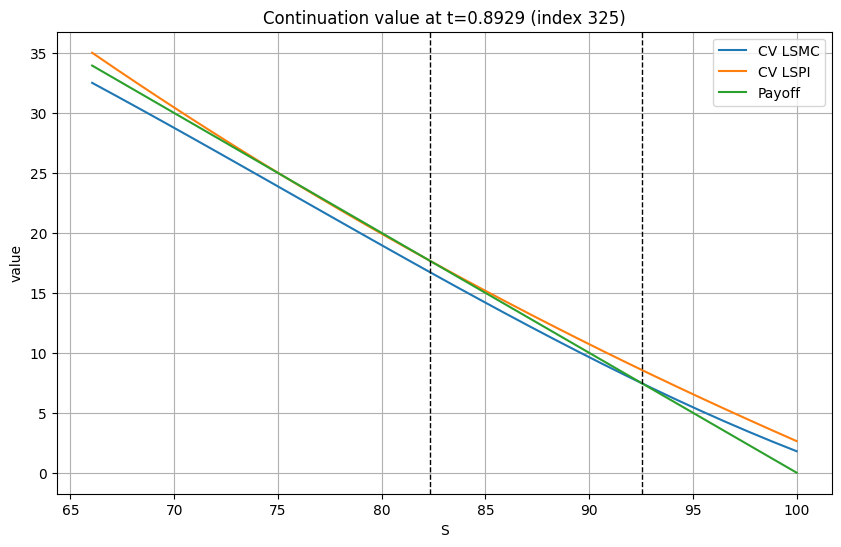

exercise boundary:  89%|████████▉ | 326/365 [00:03<00:00, 85.44it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

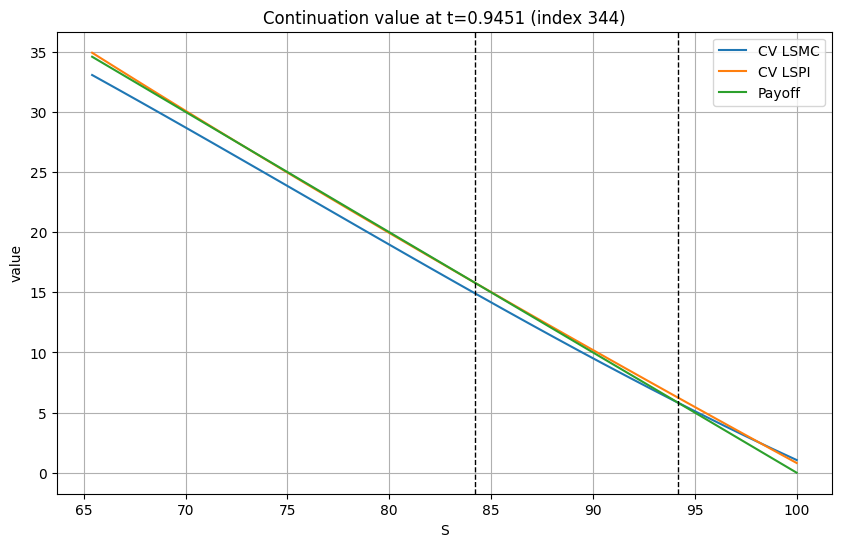

exercise boundary:  95%|█████████▍| 345/365 [00:04<00:00, 85.39it/s]/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(lambda xx: float(f(xx)), x_left, x_right)
/tmp/ipykernel_95160/1738790183.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = optimize.brentq(la

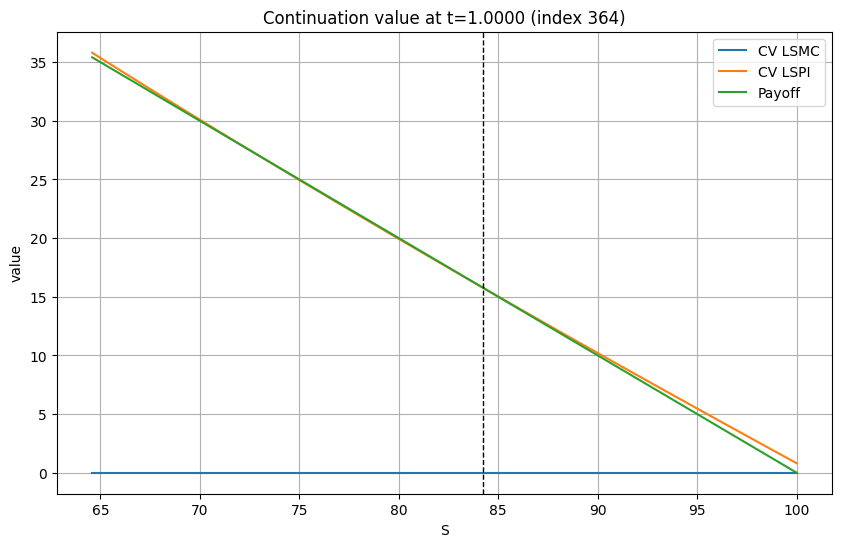

exercise boundary: 100%|██████████| 365/365 [00:04<00:00, 86.26it/s]


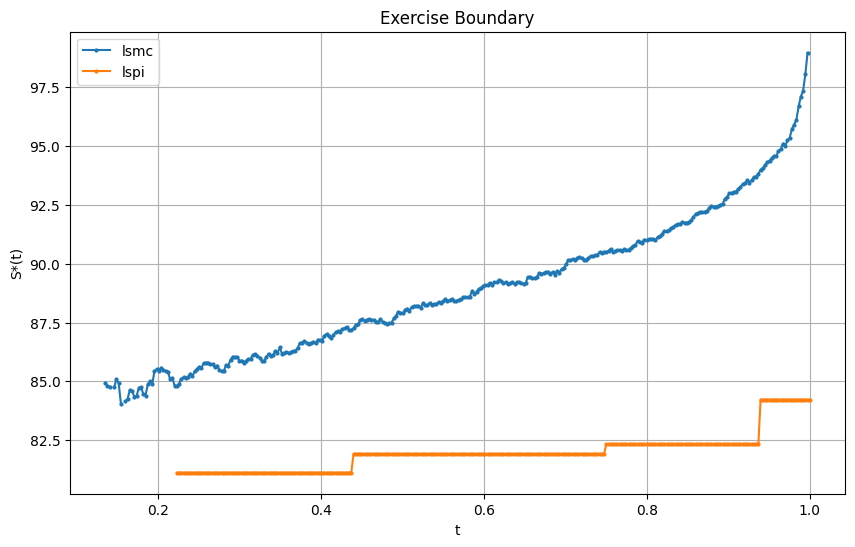

In [11]:
eb_lsmc, eb_lspi = plot_lsmc_lspi_exercise_boundary(
    amc,
    lspi,
    show_all_time_plots=True,   # если 365 картинок слишком долго/шумно, поставь False
)

In [33]:
lspi_value_slice(pricer, t_index = 0)

{'S_grid': array([ 20.        ,  20.8040201 ,  21.6080402 ,  22.4120603 ,
         23.2160804 ,  24.0201005 ,  24.8241206 ,  25.6281407 ,
         26.4321608 ,  27.2361809 ,  28.04020101,  28.84422111,
         29.64824121,  30.45226131,  31.25628141,  32.06030151,
         32.86432161,  33.66834171,  34.47236181,  35.27638191,
         36.08040201,  36.88442211,  37.68844221,  38.49246231,
         39.29648241,  40.10050251,  40.90452261,  41.70854271,
         42.51256281,  43.31658291,  44.12060302,  44.92462312,
         45.72864322,  46.53266332,  47.33668342,  48.14070352,
         48.94472362,  49.74874372,  50.55276382,  51.35678392,
         52.16080402,  52.96482412,  53.76884422,  54.57286432,
         55.37688442,  56.18090452,  56.98492462,  57.78894472,
         58.59296482,  59.39698492,  60.20100503,  61.00502513,
         61.80904523,  62.61306533,  63.41708543,  64.22110553,
         65.02512563,  65.82914573,  66.63316583,  67.43718593,
         68.24120603,  69.0452

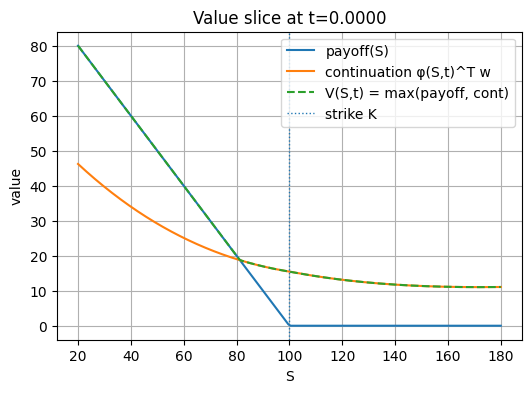

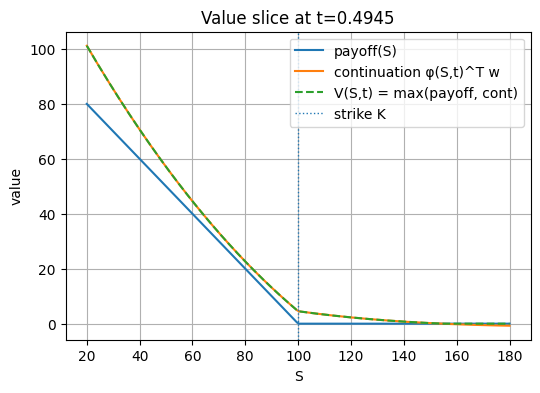

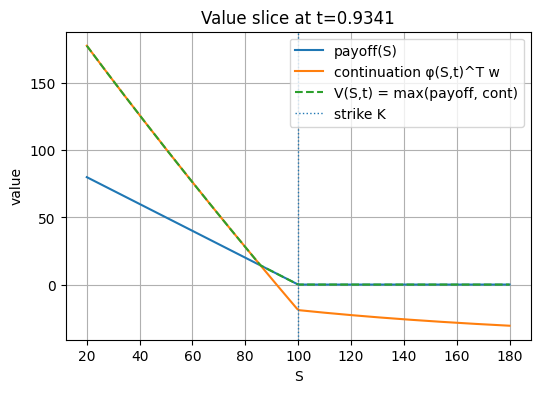

In [12]:
# t = 0
plot_lspi_value_slice(pricer, t_index=0)
plt.show()

# середина
plot_lspi_value_slice(pricer, t_index=180)
plt.show()

# почти maturity
plot_lspi_value_slice(pricer, t_index=340)
plt.show()


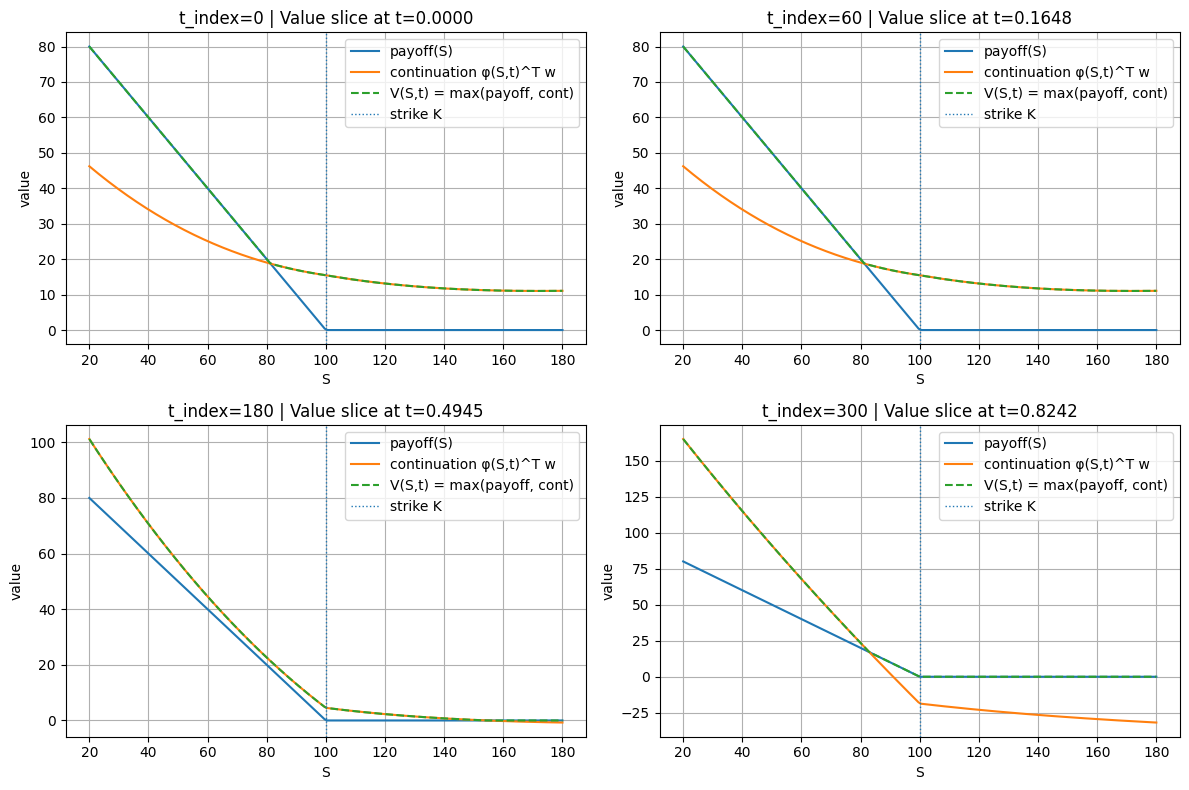

In [13]:
t_indices = [0, 60, 180, 300]
fig, axes = plot_lspi_value_slices(pricer, t_indices=t_indices)
plt.show()

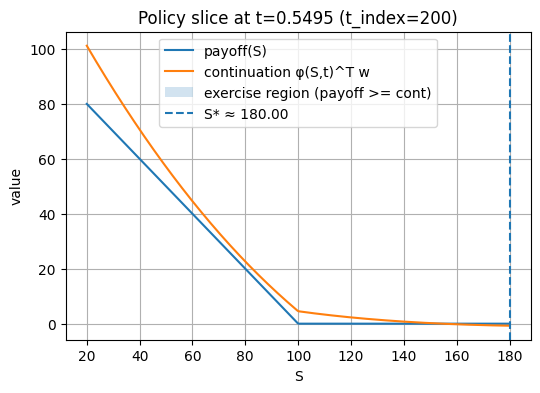

t = 0.5494505494505495
boundary S* ≈ 180.0


In [14]:
plot_lspi_policy_slice(pricer, t_index=200)
plt.show()

pol = lspi_policy_slice(pricer, t_index=200)
print("t =", pol["t"])
print("boundary S* ≈", pol["boundary_S"])


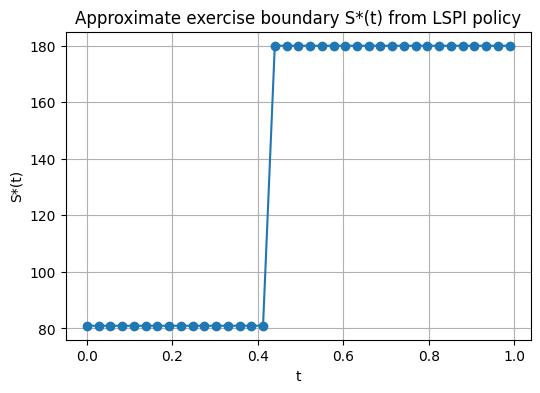

In [15]:
t_indices = range(0, len(pricer.sampler.time_grid), 10)  # каждые 10 шагов по времени
plot_lspi_exercise_boundary(pricer, t_indices=t_indices)
plt.show()
